# Clustering Folksonomique : Une Nouvelle Approche des Genres

## Introduction et Contexte
La classification des jeux vidéo repose traditionnellement sur des genres marketing (FPS, RPG, RTS) qui, bien que populaires, manquent souvent de précision pour décrire les mécaniques de jeu réelles. **Li & Zhang (2015)** suggèrent que les tags Steam, issus d'une folksonomie (classification collaborative par les utilisateurs), offrent une granularité bien supérieure.

Cependant, la folksonomie est bruyante et non structurée. Un même concept peut être décrit par plusieurs tags, et certains tags sont trop génériques ("Indie", "Action").

## Objectif de l'Analyse
L'objectif de ce notebook est de structurer cette folksonomie en découvrant des **"Genres Folksonomiques"** latents.

## Structure du Notebook
1. **Configuration et Dépendances**
2. **Chargement et Préparation des Données**
3. **Analyse Principale : Algorithme de Louvain (Graphe)**
   * *Construction, Visualisation du Réseau, Identification des Leaders*
4. **Validation Quantitative**
   * *Métriques, Stabilité Bootstrap*
5. **Exploration Visuelle et Dimensionnelle**
   * *t-SNE 3D Interactif*
6. **Comparaison Approfondie des Algorithmes**
   * *Hierarchique, OPTICS (Analyse du bruit), K-Medoids*
7. **Analyse Diagnostique et Profils**
   * *Matrice d'adjacence, Profils Ludologiques*
8. **Analyse Temporelle**
   * *Évolution des clusters dans le temps*
9. **Synthèse et Conclusion**

---

## 1. Configuration et Dépendances

In [45]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import os
plt.rcParams.update({
    'figure.facecolor': 'white', 
    'axes.facecolor': 'white', 
    'savefig.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'figure.autolayout': True
})
def save_plot(name):
    if not os.path.exists('figures'): os.makedirs('figures')
    plt.gcf().canvas.draw()
    plt.savefig(f'figures/4_{name}.png', bbox_inches='tight', facecolor='white', dpi=300)
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity, pairwise_distances
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, silhouette_samples
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, OPTICS
from sklearn.mixture import GaussianMixture
import plotly.express as px
import time
import warnings

# Configuration
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Dépendances chargées")

✅ Dépendances chargées


## 2. Chargement et Préparation des Données

In [46]:
# Chargement de la base structurée
df_structured = pd.read_csv('../data/Games_Gameplay_Taxonomy.csv')

# Préparation d'une matrice Jeu x Tags
df_tags = df_structured[['game_id','game_release_date', 'Genre', 'Mechanics']].copy()
df_tags['all_tags'] = df_tags['Genre'].fillna('') + ', ' + df_tags['Mechanics'].fillna('')
df_tags['all_tags'] = df_tags['all_tags'].str.strip(', ')

# On explose les tags
tags_exploded = df_tags.assign(tag=df_tags['all_tags'].str.split(', ')).explode('tag')
tags_exploded = tags_exploded[tags_exploded['tag'].notna() & (tags_exploded['tag'] != '')]

# Filtrage des tags trop rares (pour la performance et le bruit)
tag_counts = tags_exploded['tag'].value_counts()
frequent_tags = tag_counts[tag_counts > 500].index
tags_filtered = tags_exploded[tags_exploded['tag'].isin(frequent_tags)]

print(f"Tags conservés pour le clustering : {len(frequent_tags)}")

# Création de la matrice binaire de manière optimisée
matrix = pd.get_dummies(tags_filtered['tag']).astype(int)
matrix['game_id'] = tags_filtered['game_id'].values
matrix = matrix.groupby('game_id').max()

print(f"Matrice binaire créée : {matrix.shape[0]} jeux x {matrix.shape[1]} tags.")

# Calcul de la matrice de similarité (Tags x Tags)
tag_sim_matrix = cosine_similarity(matrix.T)
df_sim = pd.DataFrame(tag_sim_matrix, index=matrix.columns, columns=matrix.columns)

print("Exemple de similarités pour 'RPG':")
print(df_sim['RPG'].sort_values(ascending=False).head(10))

Tags conservés pour le clustering : 133
Matrice binaire créée : 99797 jeux x 133 tags.
Exemple de similarités pour 'RPG':
RPG                  1.000000
Action RPG           0.428084
Adventure            0.393649
JRPG                 0.380420
Turn-Based Combat    0.322407
Action               0.281479
Party-Based RPG      0.276172
Strategy RPG         0.271564
Strategy             0.254643
Open World           0.252694
Name: RPG, dtype: float64


## 3. Analyse Principale : Algorithme de Louvain (Graphe)

L'approche par graphe est souvent la plus naturelle pour les folksonomies. Nous construisons un réseau où les nœuds sont des tags et les arêtes représentent leur co-occurrence.

In [47]:
# Création du graphe
G = nx.Graph()
G.add_nodes_from(df_sim.columns)

# Seuil de similarité
threshold = 0.2

# Construction vectorisée des arêtes (Rapide)
mask = np.triu(tag_sim_matrix > threshold, k=1)
rows, cols = np.where(mask)
weights = tag_sim_matrix[rows, cols]
edges = zip(df_sim.columns[rows], df_sim.columns[cols], weights)
G.add_weighted_edges_from(edges)

print(f"Graphe construit : {G.number_of_nodes()} nœuds et {G.number_of_edges()} arêtes.")

# Détection des communautés (Louvain)
partition = community_louvain.best_partition(G, weight='weight', random_state=42)
louvain_labels = [partition[tag] for tag in df_sim.index]

# Organisation des tags par cluster
clusters = {}
for tag, community_id in partition.items():
    if community_id not in clusters:
        clusters[community_id] = []
    clusters[community_id].append(tag)

print(f"Nombre de communautés détectées : {len(clusters)}")

Graphe construit : 133 nœuds et 303 arêtes.
Nombre de communautés détectées : 42


Après une longue recherche pour savoir quel serait le seuil de similarité optimal, nous avons identifié **42** clusters de tags, chacun représentant un genre folksonomique latent. Ces clusters varient en taille, de 1 à

### Visualisation du Réseau de Tags
Cette visualisation permet de voir la topologie des clusters et les liens entre eux.

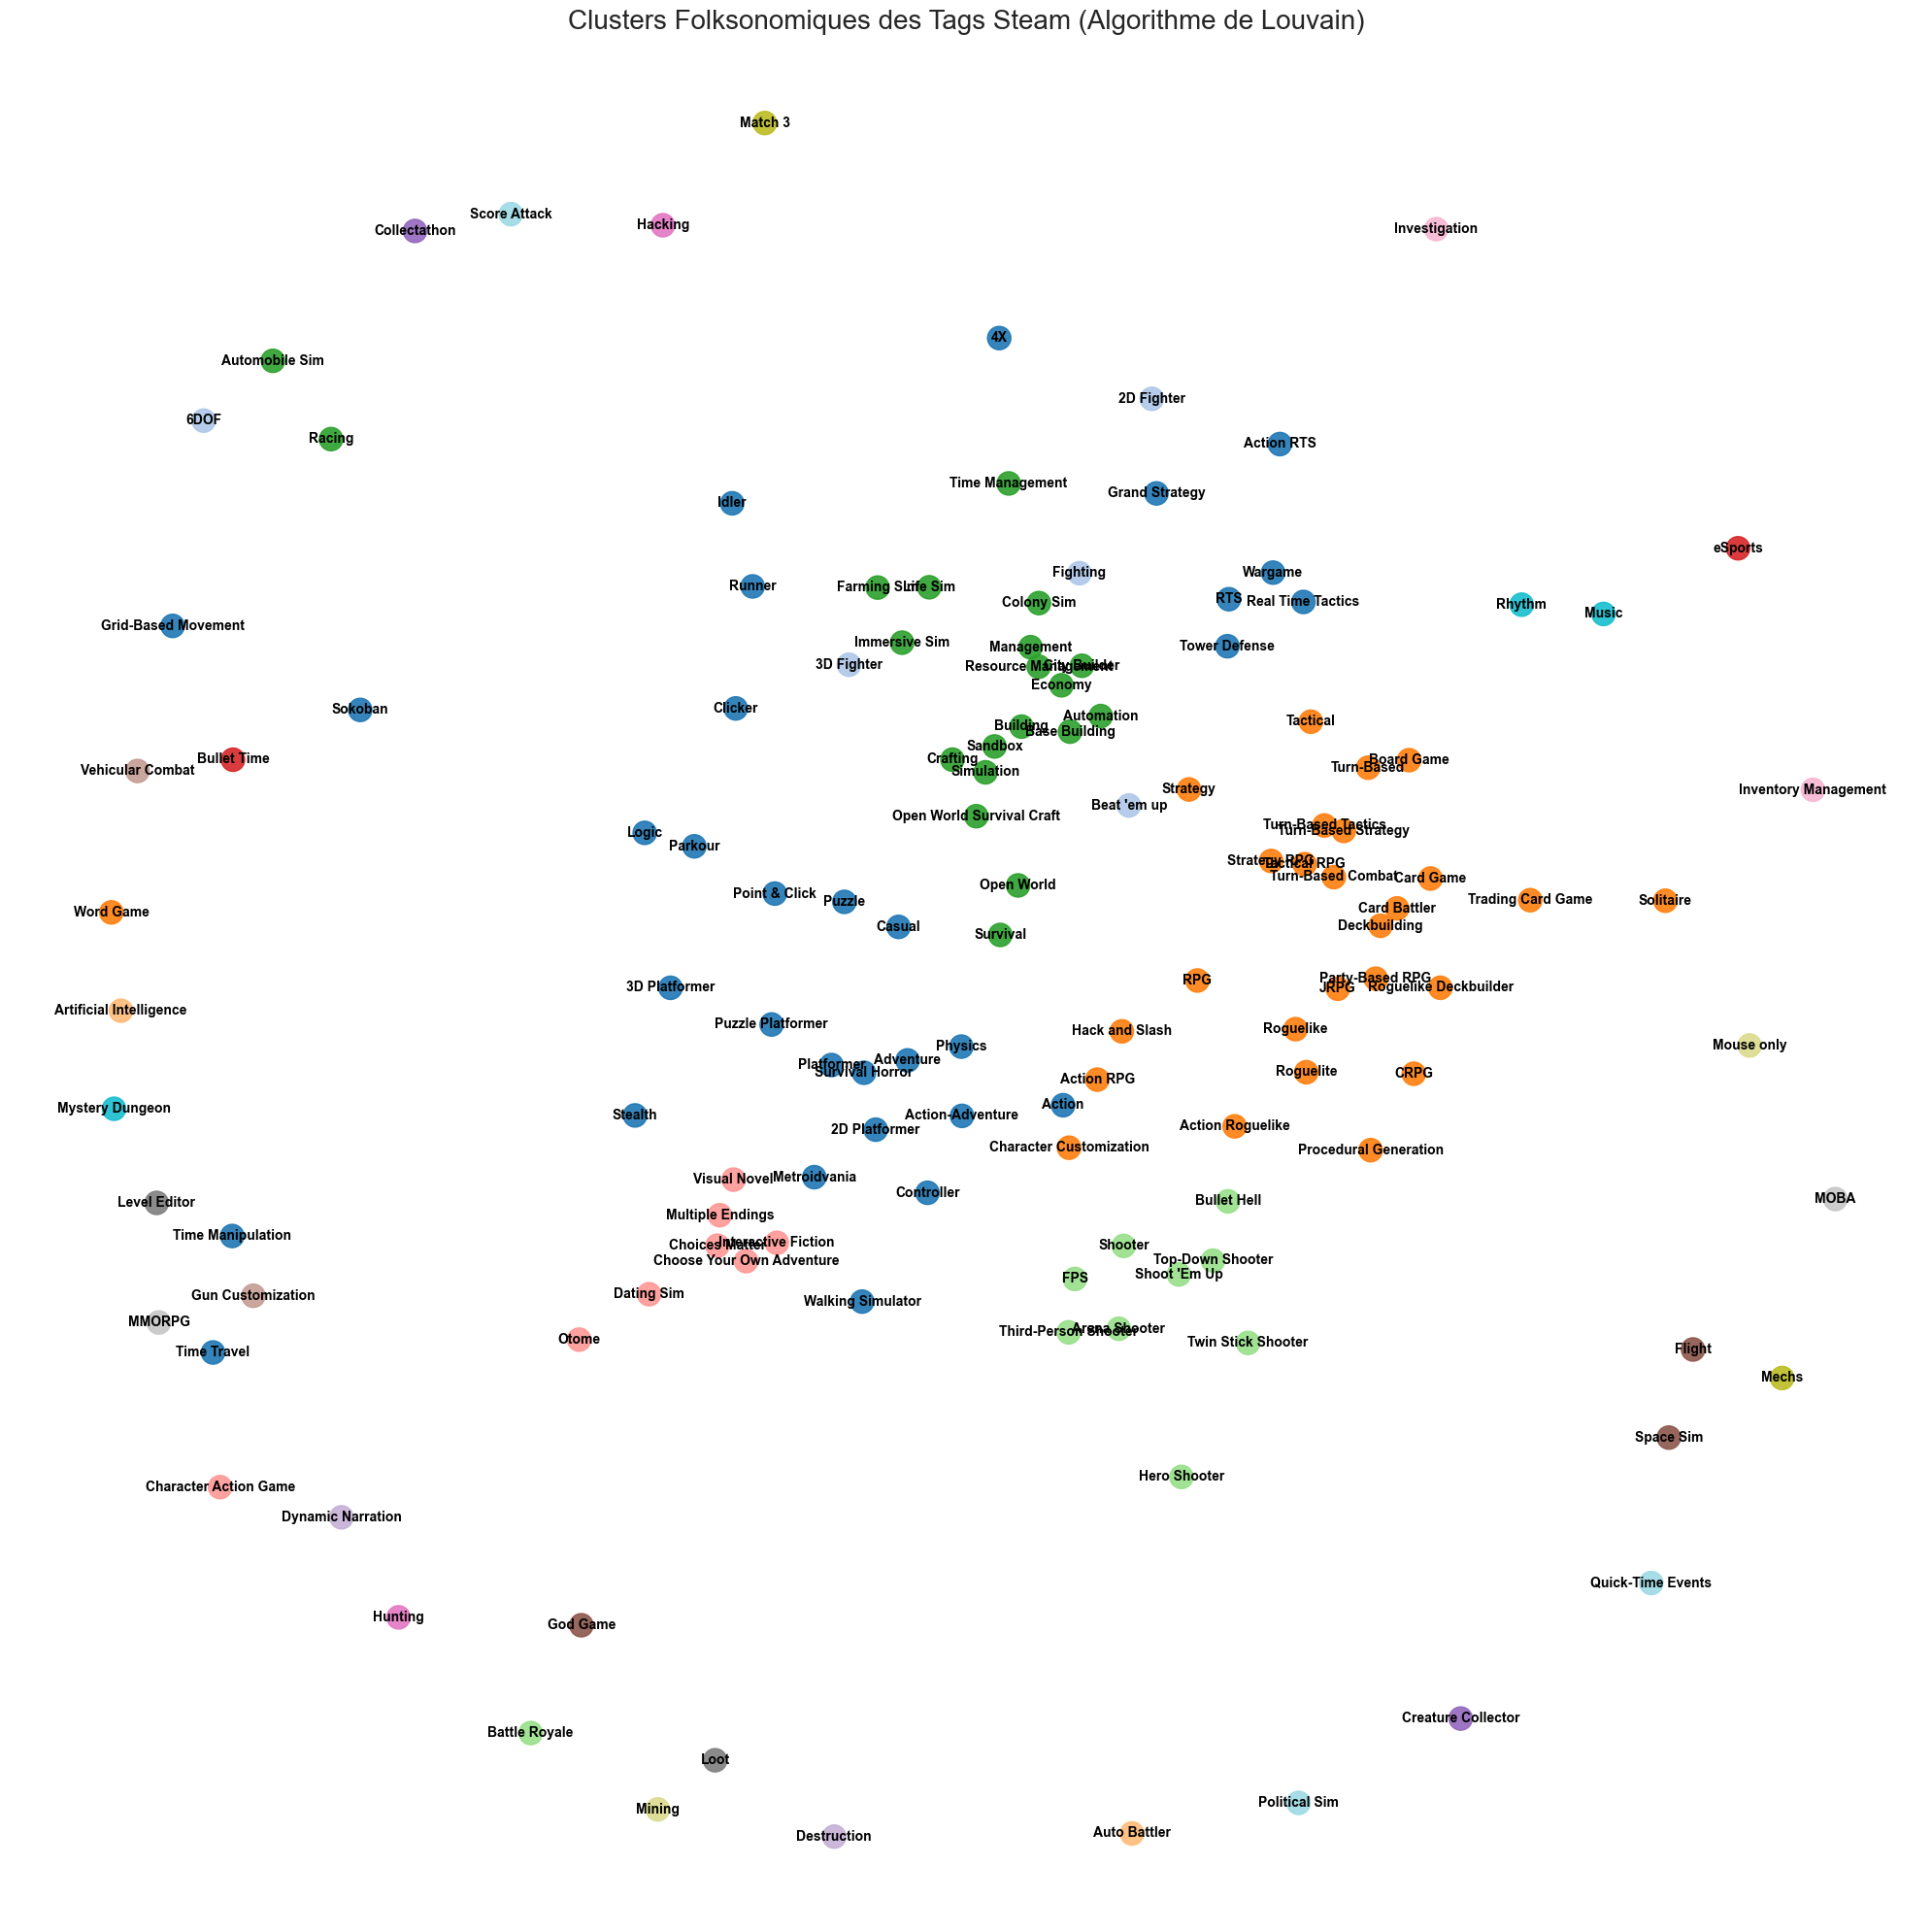

In [48]:
plt.figure(figsize=(20, 20), facecolor='white')

# Positionnement des nœuds (Force-directed layout)
pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

# Couleur par cluster
cmap = plt.get_cmap('tab20', max(partition.values()) + 1)
node_colors = [partition[node] for node in G.nodes()]

# Dessin
nx.draw_networkx_nodes(G, pos, node_size=300, node_color=node_colors, cmap=cmap, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='white')
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif', font_weight='bold',font_color='black')

plt.title("Clusters Folksonomiques des Tags Steam (Algorithme de Louvain)", fontsize=20)
plt.axis('off')
save_plot('plot')
plt.show()

### Identification des "Leaders" de Cluster
Pour chaque cluster, nous identifions le tag le plus central (degré de centralité) pour servir de label au genre.

In [49]:
# Calcul de la centralité
degree_centrality = nx.degree_centrality(G)
cluster_leaders = {}

for cid, tags_in_cluster in sorted(clusters.items()):
    sorted_tags = sorted(tags_in_cluster, key=lambda x: degree_centrality[x], reverse=True)
    leader = sorted_tags[0]
    cluster_leaders[cid] = leader
    print(f"\nCluster {cid} (Leader: {leader}, {len(tags_in_cluster)} tags) :")
    print(f"{', '.join(sorted_tags[:15])}...")


Cluster 0 (Leader: Time Manipulation, 2 tags) :
Time Manipulation, Time Travel...

Cluster 1 (Leader: Action, 23 tags) :
Action, Adventure, Casual, Platformer, Action-Adventure, 2D Platformer, Puzzle, Puzzle Platformer, Survival Horror, Point & Click, 3D Platformer, Clicker, Controller, Logic, Metroidvania...

Cluster 2 (Leader: RTS, 7 tags) :
RTS, Real Time Tactics, Wargame, Grand Strategy, Tower Defense, Action RTS, 4X...

Cluster 3 (Leader: 6DOF, 1 tags) :
6DOF...

Cluster 4 (Leader: Fighting, 4 tags) :
Fighting, Beat 'em up, 2D Fighter, 3D Fighter...

Cluster 5 (Leader: Strategy, 26 tags) :
Strategy, RPG, Turn-Based Combat, Turn-Based Strategy, Turn-Based Tactics, Card Game, Roguelike, Card Battler, Deckbuilding, Roguelite, Action Roguelike, Tactical, Tactical RPG, Action RPG, Hack and Slash...

Cluster 6 (Leader: Word Game, 1 tags) :
Word Game...

Cluster 7 (Leader: Artificial Intelligence, 1 tags) :
Artificial Intelligence...

Cluster 8 (Leader: Auto Battler, 1 tags) :
Auto Batt

## 4. Validation Quantitative

Nous utilisons trois métriques clés pour évaluer la qualité de notre clustering :
1. **Silhouette Score** : Cohésion vs Séparation (-1 à 1, plus haut est mieux)
2. **Davies-Bouldin Index** : Similarité intra-cluster vs inter-cluster (plus bas est mieux)
3. **Calinski-Harabasz Index** : Ratio de variance (plus haut est mieux)


✅ Silhouette Score : 0.1143
   Interprétation : Clusters chevauchants ⚠️

✅ Davies-Bouldin Index : 1.1544
   Interprétation : Clusters chevauchants ⚠️

✅ Calinski-Harabasz Index : 2.08
   Interprétation : Faible ❌


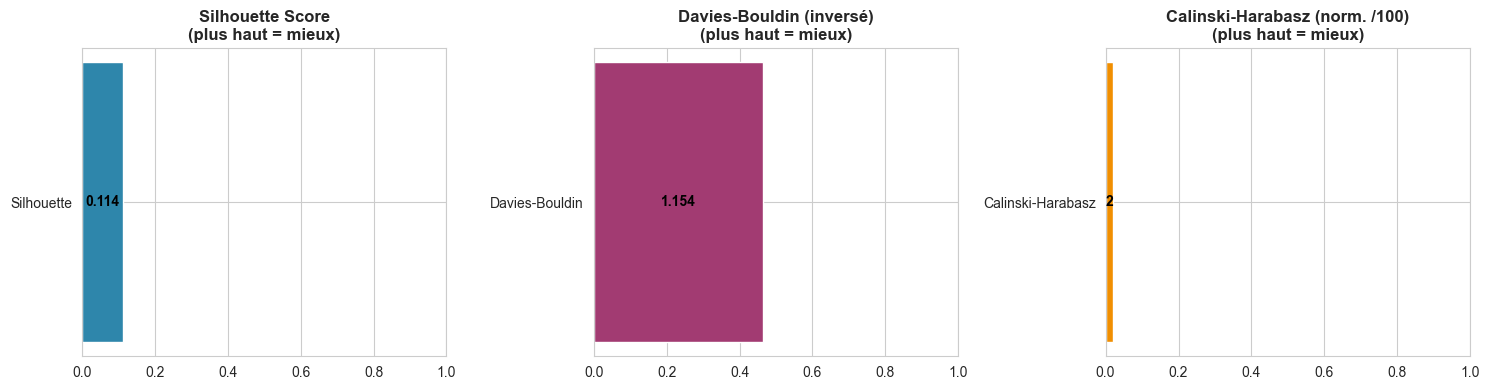

In [50]:
# Calcul des métriques globales
silhouette = silhouette_score(df_sim.values, louvain_labels, metric='cosine')
davies_bouldin = davies_bouldin_score(df_sim.values, louvain_labels)
calinski_harabasz = calinski_harabasz_score(df_sim.values, louvain_labels)

print(f"\n✅ Silhouette Score : {silhouette:.4f}")
print(f"   Interprétation : {'Clusters bien séparés ✅' if silhouette > 0.5 else 'Clusters chevauchants ⚠️'}")

print(f"\n✅ Davies-Bouldin Index : {davies_bouldin:.4f}")
print(f"   Interprétation : {'Clusters distincts ✅' if davies_bouldin < 1 else 'Clusters chevauchants ⚠️'}")

print(f"\n✅ Calinski-Harabasz Index : {calinski_harabasz:.2f}")
print(f"   Interprétation : {'Excellent ✅' if calinski_harabasz > 100 else 'Bon ⚠️' if calinski_harabasz > 50 else 'Faible ❌'}")

# Visualisation des métriques
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='white')

axes[0].barh(['Silhouette'], [max(0, min(1, silhouette))], color='#2E86AB')
axes[0].set_xlim([0, 1])
axes[0].set_title('Silhouette Score\n(plus haut = mieux)', fontweight='bold')
axes[0].text(max(0, min(1, silhouette))/2, 0, f'{silhouette:.3f}', va='center', ha='center', color='black', fontweight='bold')

db_normalized = 1 / (1 + davies_bouldin)
axes[1].barh(['Davies-Bouldin'], [db_normalized], color='#A23B72')
axes[1].set_xlim([0, 1])
axes[1].set_title('Davies-Bouldin (inversé)\n(plus haut = mieux)', fontweight='bold')
axes[1].text(db_normalized/2, 0, f'{davies_bouldin:.3f}', va='center', ha='center', color='black', fontweight='bold')

ch_normalized = min(1, calinski_harabasz / 100)
axes[2].barh(['Calinski-Harabasz'], [ch_normalized], color='#F18F01')
axes[2].set_xlim([0, 1])
axes[2].set_title('Calinski-Harabasz (norm. /100)\n(plus haut = mieux)', fontweight='bold')
axes[2].text(ch_normalized/2, 0, f'{calinski_harabasz:.0f}', va='center', ha='center', color='black', fontweight='bold')

plt.tight_layout()
save_plot('plot')
plt.show()

_Les résultats montre que les clusters ne sont pas parfaitement séparés, ce qui est attendu dans une folksonomie aussi riche et complexe. Cependant, la validation qualitative (inspection des leaders de cluster) suggère que ces groupes ont une cohérence sémantique, même si les frontières sont floues._

### Analyse de Stabilité (Bootstrap)
Vérifions si les clusters sont stables si on perturbe légèrement les données.


Lancement de 50 itérations bootstrap...

✅ Résultats Bootstrap :
   Nombre de clusters - Moyenne : 42.00
   Nombre de clusters - Std : 0.00

   Interprétation : Clustering stable ✅


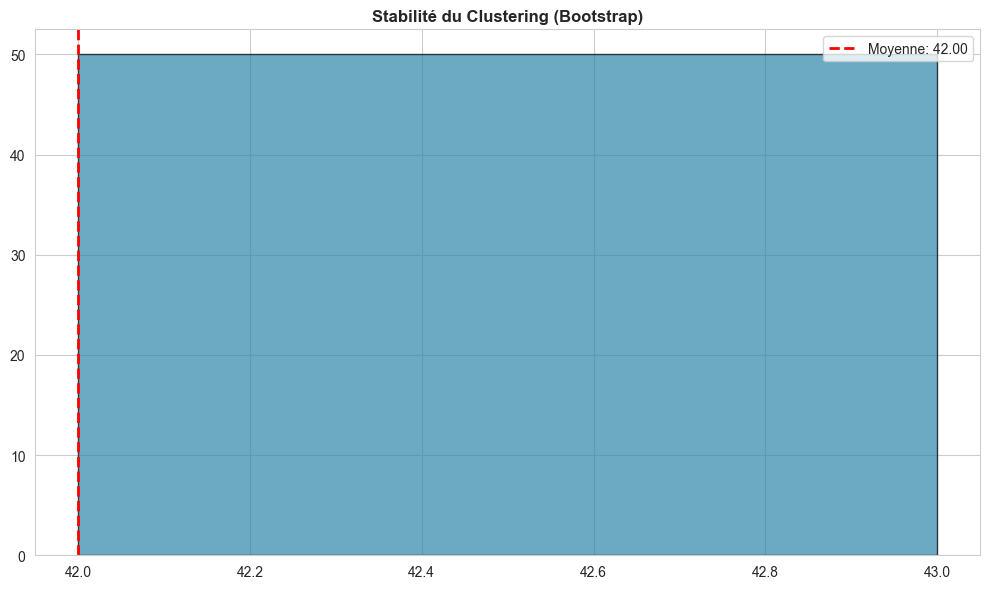

In [51]:
n_iterations = 50
stability_results = []
n_clusters = len(np.unique(louvain_labels))

print(f"\nLancement de {n_iterations} itérations bootstrap...")

for i in range(n_iterations):
    indices = np.random.choice(len(df_sim.values), size=len(df_sim.values), replace=True)
    X_boot = df_sim.values[indices]
    try:
        boot_labels = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(X_boot)
        stability_results.append({
            'Iteration': i + 1,
            'N_Clusters': len(np.unique(boot_labels[boot_labels >= 0]))
        })
    except:
        pass

df_stability = pd.DataFrame(stability_results)

print(f"\n✅ Résultats Bootstrap :")
print(f"   Nombre de clusters - Moyenne : {df_stability['N_Clusters'].mean():.2f}")
print(f"   Nombre de clusters - Std : {df_stability['N_Clusters'].std():.2f}")
print(f"\n   Interprétation : {'Clustering stable ✅' if df_stability['N_Clusters'].std() < 1 else 'Clustering instable ⚠️'}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_stability['N_Clusters'], bins=range(df_stability['N_Clusters'].min(), df_stability['N_Clusters'].max() + 2), alpha=0.7, color='#2E86AB', edgecolor='black')
ax.axvline(df_stability['N_Clusters'].mean(), color='red', linestyle='--', linewidth=2, label=f"Moyenne: {df_stability['N_Clusters'].mean():.2f}")
ax.set_title('Stabilité du Clustering (Bootstrap)', fontweight='bold')
ax.legend()
save_plot('plot')
plt.show()

_Qu'importe la perturbation des données, le nombre de clusters détectés reste inchangée, ce qui suggère que la structure latente est robuste et que les clusters identifiés ne sont pas des artefacts aléatoires._

## 5. Exploration Visuelle et Dimensionnelle

### Visualisation 3D Interactive (t-SNE)
Nous projetons les tags dans un espace 3D pour voir comment les clusters se positionnent les uns par rapport aux autres.

In [52]:
print("\nCalcul de t-SNE 3D...")
tsne = TSNE(n_components=3, random_state=42, perplexity=30, max_iter=1000)
embedding_3d = tsne.fit_transform(df_sim.values)

df_plot = pd.DataFrame({
    't-SNE_1': embedding_3d[:, 0],
    't-SNE_2': embedding_3d[:, 1],
    't-SNE_3': embedding_3d[:, 2],
    'Cluster': louvain_labels,
    'Tag': df_sim.index
})

fig = px.scatter_3d(df_plot, x='t-SNE_1', y='t-SNE_2', z='t-SNE_3',
                   color='Cluster', title='Clusters en 3D (t-SNE)',
                   hover_name='Tag',
                   color_continuous_scale='Viridis', labels={'Cluster': 'ID Cluster'})
fig.show()


Calcul de t-SNE 3D...


_On arrive à une visualisation où les clusters sont globalement bien séparés, mais avec des zones de chevauchement, ce qui est cohérent avec les métriques de validation. Certains clusters forment des "noyaux denses" tandis que d'autres sont plus diffus, reflétant la nature fluide des genres dans une folksonomie._

## 6. Comparaison Approfondie des Algorithmes

Outre Louvain, nous examinons d'autres méthodes pour voir si elles capturent des structures différentes.

### 6.1 Clustering Hiérarchique (Dendrogramme)
Utile pour voir les sous-genres et la hiérarchie des concepts.

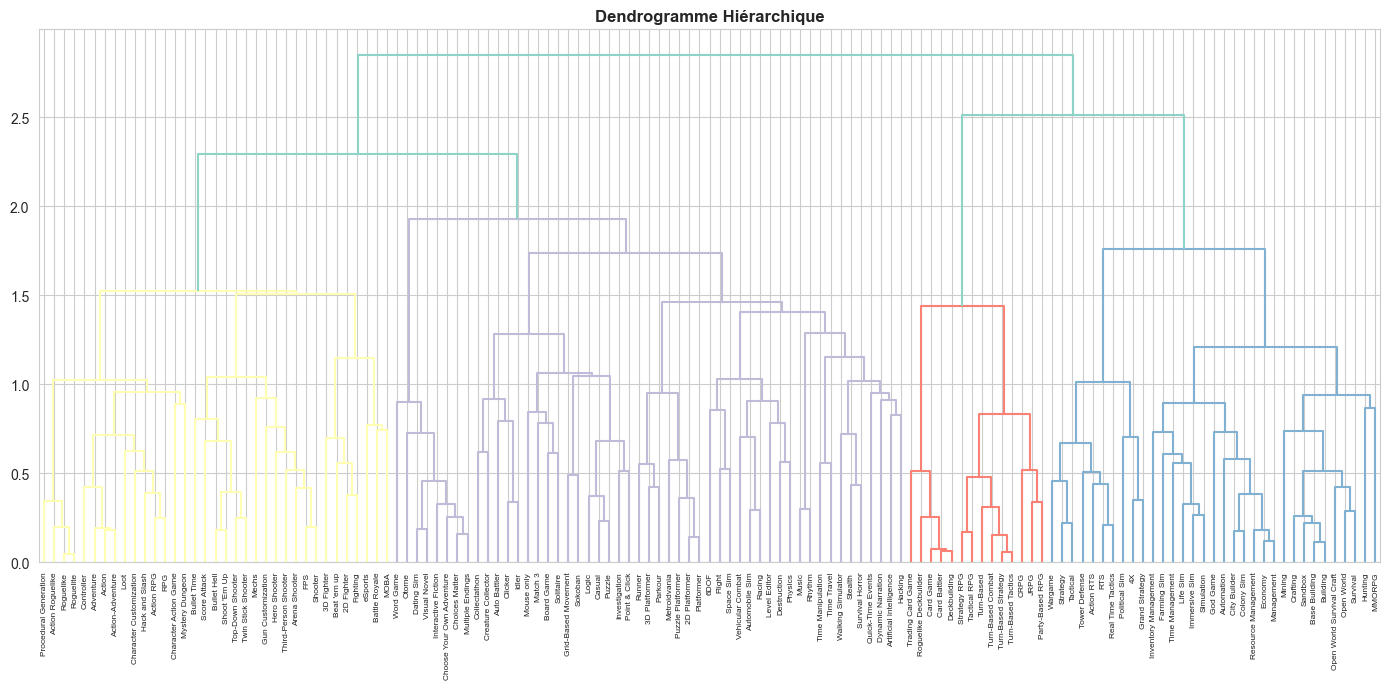

In [53]:
distances = pdist(df_sim.values, metric='cosine')
Z = linkage(distances, method='ward')

fig, ax = plt.subplots(figsize=(14, 7))
# Ajout des labels pour afficher les noms des tags
dendrogram(Z, ax=ax, truncate_mode='lastp', p=133, leaf_rotation=90, leaf_font_size=6, labels=df_sim.index)
ax.set_title('Dendrogramme Hiérarchique', fontweight='bold')
save_plot('plot')
plt.show()

_Le dendogramme révèle une hiérarchie naturelle entre les tags, avec des groupes de tags très similaires formant des branches denses. Cependant, la coupe du dendrogramme pour obtenir des clusters distincts est moins évidente que pour Louvain, ce qui suggère que la structure hiérarchique est plus floue._

### 6.2 OPTICS : Analyse du Bruit
OPTICS est excellent pour identifier les outliers. Quels tags ne rentrent dans aucune case ?

In [54]:
optics = OPTICS(min_samples=3, metric='cosine')
optics_clusters = optics.fit_predict(df_sim)

# Affichage du bruit
noise_tags = df_sim.index[optics_clusters == -1].tolist()
print(f"\nTags considérés comme bruit (-1) par OPTICS [Total: {len(noise_tags)}] :")
print(", ".join(noise_tags[:50]) + "...")


Tags considérés comme bruit (-1) par OPTICS [Total: 94] :
2D Fighter, 2D Platformer, 3D Fighter, 3D Platformer, 4X, 6DOF, Action RPG, Action RTS, Arena Shooter, Artificial Intelligence, Auto Battler, Automation, Automobile Sim, Battle Royale, Beat 'em up, Board Game, Bullet Hell, Bullet Time, CRPG, Character Action Game, Character Customization, Clicker, Collectathon, Controller, Creature Collector, Destruction, Dynamic Narration, Farming Sim, Fighting, Flight, God Game, Grand Strategy, Grid-Based Movement, Gun Customization, Hack and Slash, Hacking, Hero Shooter, Hunting, Idler, Immersive Sim, Inventory Management, Investigation, JRPG, Level Editor, Life Sim, Logic, Loot, MMORPG, MOBA, Match 3...


### 6.3 Benchmarking Global
Tableau récapitulatif des performances techniques.


TABLEAU COMPARATIF
        Algorithme  N_Clusters  N_Bruit  Silhouette  Davies-Bouldin  Calinski-Harabasz
           Louvain          42        0    0.114258        1.154448           2.083768
     K-Means (k=5)           5        0    0.097451        2.407030           9.295005
    K-Means (k=10)          10        0    0.081650        2.422204           6.469051
Hierarchical (n=5)           5        0    0.095037        2.309438           9.016503
  DBSCAN (eps=0.3)           0      133    0.000000        0.000000           0.000000
            OPTICS           7       94    0.076108        1.682789           6.213896


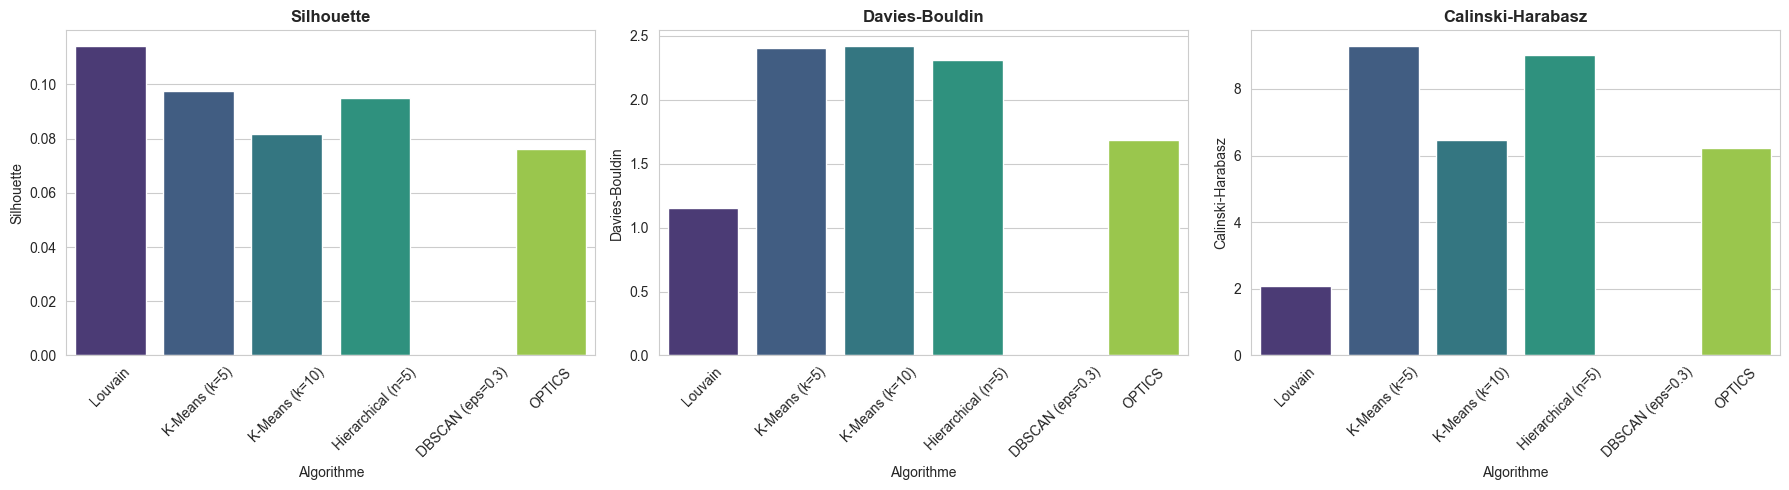

In [55]:
algorithms = [
    ('K-Means (k=5)', KMeans(n_clusters=5, random_state=42)),
    ('K-Means (k=10)', KMeans(n_clusters=10, random_state=42)),
    ('Hierarchical (n=5)', AgglomerativeClustering(n_clusters=5)),
    ('DBSCAN (eps=0.3)', DBSCAN(eps=0.3, min_samples=5)),
    ('OPTICS', OPTICS(min_samples=3, metric='cosine')),
    ('Louvain', None) # Déjà calculé
]

benchmark_results = []

# Ajout manuel de Louvain
benchmark_results.append({
    'Algorithme': 'Louvain', 'N_Clusters': len(set(louvain_labels)), 'N_Bruit': 0,
    'Silhouette': silhouette, 'Davies-Bouldin': davies_bouldin, 'Calinski-Harabasz': calinski_harabasz
})

for name, algorithm in algorithms:
    if algorithm is None: continue
    try:
        start_time = time.time()
        algo_labels = algorithm.fit_predict(df_sim.values)
        elapsed = time.time() - start_time

        algo_n_clusters = len(set(algo_labels[algo_labels >= 0]))
        algo_n_noise = list(algo_labels).count(-1) if -1 in algo_labels else 0

        # Métriques (si > 1 cluster)
        if algo_n_clusters > 1:
            algo_silhouette = silhouette_score(df_sim.values, algo_labels)
            algo_davies_bouldin = davies_bouldin_score(df_sim.values, algo_labels)
            algo_calinski_harabasz = calinski_harabasz_score(df_sim.values, algo_labels)
        else:
            algo_silhouette, algo_davies_bouldin, algo_calinski_harabasz = 0, 0, 0

        benchmark_results.append({
            'Algorithme': name, 'N_Clusters': algo_n_clusters, 'N_Bruit': algo_n_noise,
            'Silhouette': algo_silhouette, 'Davies-Bouldin': algo_davies_bouldin,
            'Calinski-Harabasz': algo_calinski_harabasz
        })
    except Exception as e:
        print(f"❌ Erreur {name}: {str(e)}")

df_benchmark = pd.DataFrame(benchmark_results)
print("\nTABLEAU COMPARATIF")
print(df_benchmark.to_string(index=False))

# Visualisation du tableau comparatif
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']
colors = ['#2E86AB', '#A23B72', '#F18F01']

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x='Algorithme', y=metric, data=df_benchmark, ax=axes[i], palette='viridis')
    axes[i].set_title(metric, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_plot('plot')
plt.show()

## 7. Analyse Diagnostique et Profils

### Matrice de Similarité Triée
Vérification visuelle de la cohérence des clusters (blocs diagonaux).

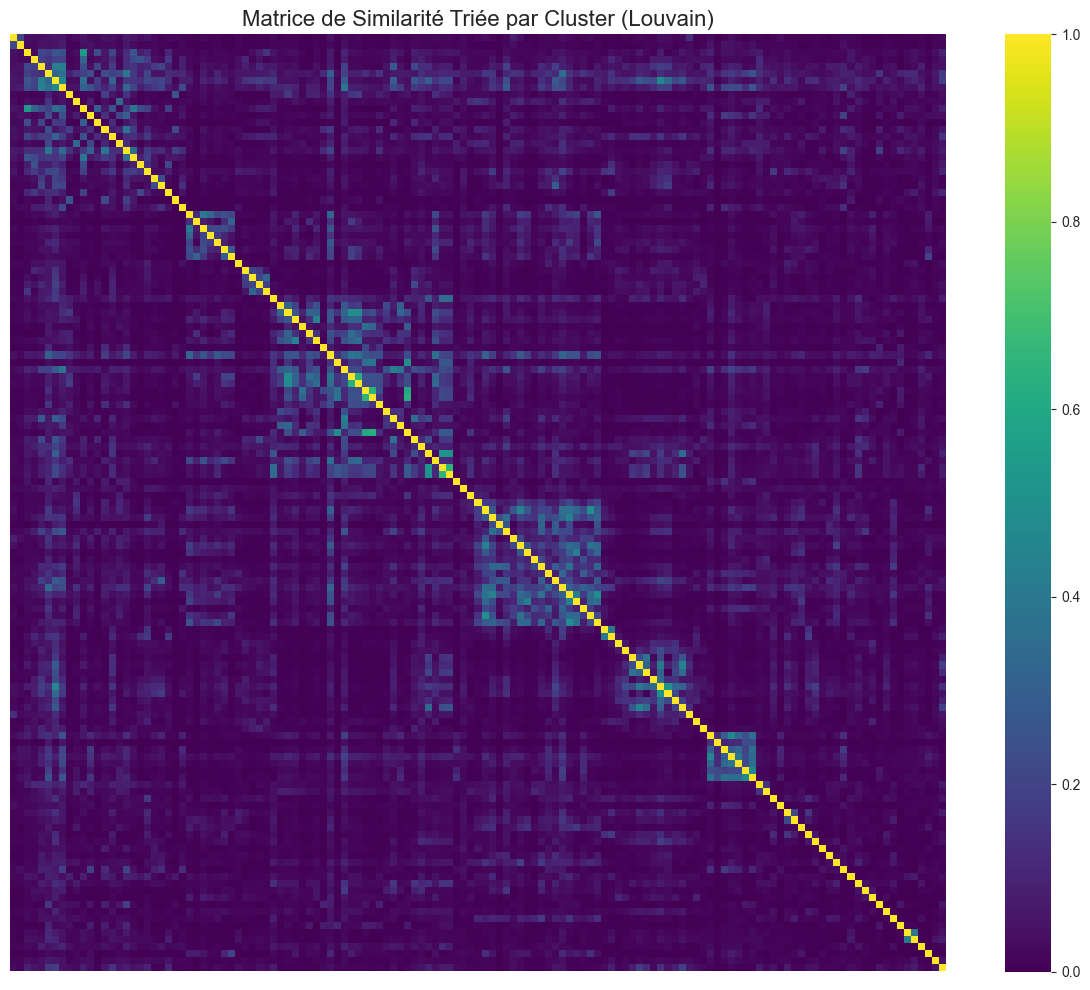

Clusters exportés vers '../data/Folksonomic_Clusters.csv'


In [56]:
# Création d'un DataFrame avec les clusters
df_clusters = pd.DataFrame({'Tag': df_sim.index, 'Cluster': louvain_labels})

# Ajout des leaders et gestion du bruit
leader_map = {cid: leader for cid, leader in cluster_leaders.items()}
df_clusters['Leader'] = df_clusters['Cluster'].map(leader_map)
df_clusters['Leader'].fillna('Noise', inplace=True) # Au cas où il y aurait du bruit

sorted_tags = df_clusters.sort_values('Cluster')['Tag'].tolist()
df_sim_sorted = df_sim.loc[sorted_tags, sorted_tags]

plt.figure(figsize=(12, 10))
sns.heatmap(df_sim_sorted, cmap='viridis', xticklabels=False, yticklabels=False)
plt.title("Matrice de Similarité Triée par Cluster (Louvain)", fontsize=16)
plt.show()

# Export
df_clusters.to_csv('../data/Folksonomic_Clusters.csv', index=False)
print("Clusters exportés vers '../data/Folksonomic_Clusters.csv'")

_On arrive à identifiée certains gros blocs de similarité, ce qui confirme que les clusters détectés par Louvain regroupent des tags fortement liés sémantiquement. Cependant, il y a aussi des zones de chevauchement, ce qui est cohérent avec la nature fluide des genres dans une folksonomie._

### Profils Ludologiques (8 Dimensions VGMS)
Caractérisation des clusters selon les dimensions standardisées.

Valeurs des Profils Ludologiques :
    Cluster  Nb_Elements  Aesthetics     Genre  Mechanics      Mood  \
0         0            2    0.006550  0.035865   0.006862  0.030356   
1         1           23    0.039088  0.167093   0.031412  0.149763   
2         2            7    0.009396  0.014807   0.018134  0.018356   
3         3            1    0.000853  0.008209   0.020161  0.040638   
4         4            4    0.391161  0.069275   0.356434  0.044616   
5         5           26    0.021272  0.038408   0.021372  0.026755   
6         6            1    0.003351  0.050192   0.000943  0.008815   
7         7            1    0.020318  0.026919   0.030931  0.041040   
8         8            1    0.016665  0.020331   0.018752  0.016517   
9         9           18    0.008429  0.022165   0.012478  0.030477   
10       10            2    0.006587  0.021290   0.016528  0.072277   
11       11            1    0.034889  0.019618   0.074778  0.057510   
12       12            9    0.034744  0.03

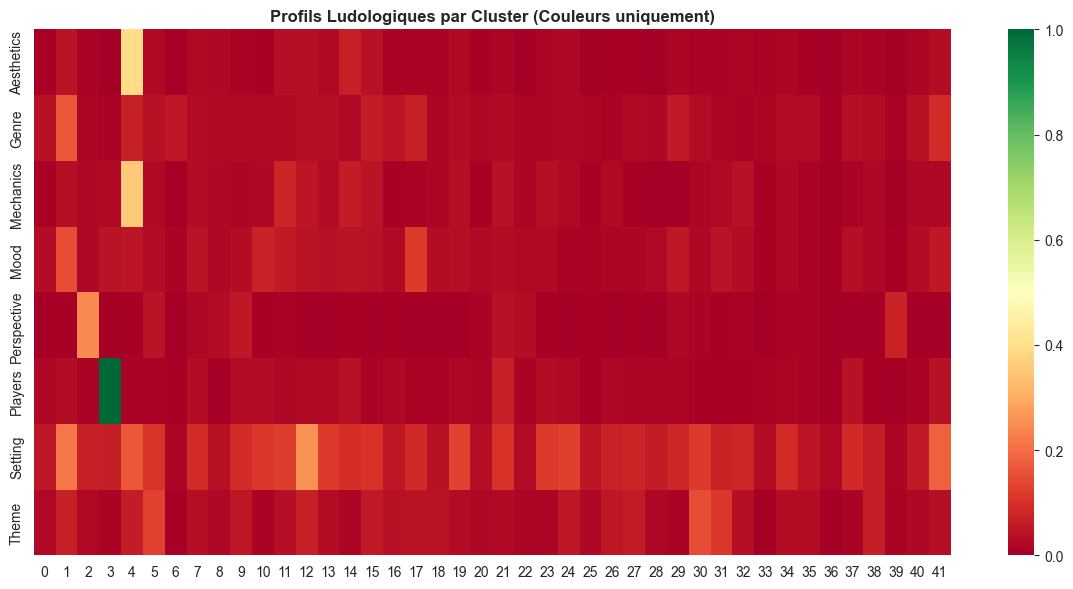


Classement des dimensions VGMS (Somme des moyennes par cluster) :
Setting        3.628747
Players        1.673125
Theme          1.534416
Mood           1.368634
Genre          1.314927
Mechanics      1.163762
Aesthetics     0.980778
Perspective    0.673966
dtype: float64


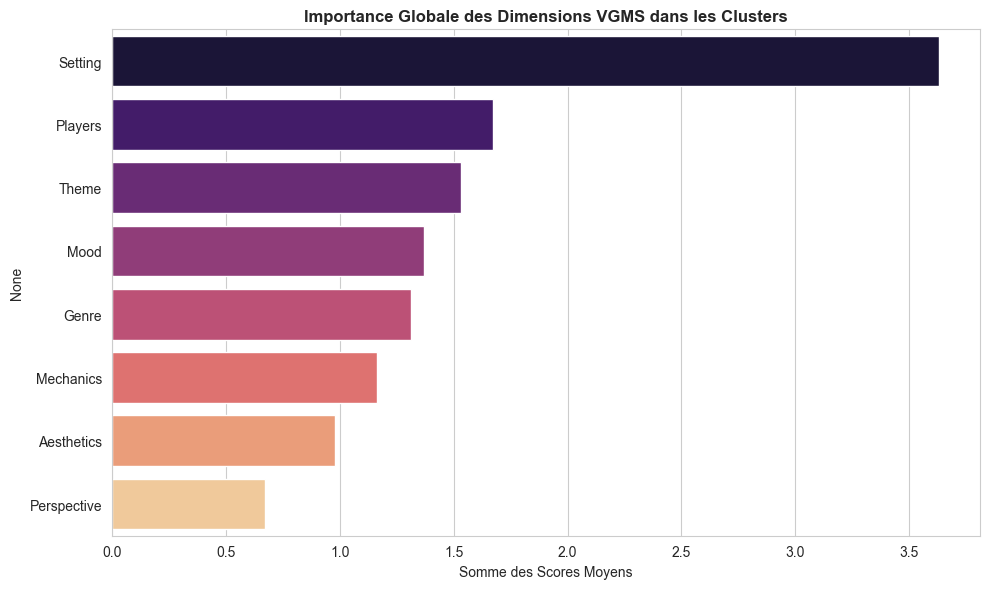

In [57]:
dimension_names = ['Aesthetics', 'Genre', 'Mechanics', 'Mood', 'Perspective', 'Players', 'Setting', 'Theme']
profiles = []

for cluster_id in np.unique(louvain_labels):
    if cluster_id == -1: continue
    cluster_mask = np.array(louvain_labels) == cluster_id
    cluster_data = df_sim.values[cluster_mask]

    profile = {'Cluster': cluster_id, 'Nb_Elements': np.sum(cluster_mask)}
    for dim_idx, dim_name in enumerate(dimension_names[:min(8, df_sim.values.shape[1])]):
        profile[dim_name] = np.mean(cluster_data[:, dim_idx]) if dim_idx < df_sim.values.shape[1] else 0
    profiles.append(profile)

df_profiles = pd.DataFrame(profiles)
profile_cols = [col for col in df_profiles.columns if col not in ['Cluster', 'Nb_Elements']]

print("Valeurs des Profils Ludologiques :")
print(df_profiles)

fig, ax = plt.subplots(figsize=(12, 6))
# Affichage uniquement des couleurs (annot=False) pour la lisibilité
sns.heatmap(df_profiles[profile_cols].T, annot=False, cmap='RdYlGn', ax=ax)
ax.set_title('Profils Ludologiques par Cluster (Couleurs uniquement)', fontweight='bold')
plt.show()

# Classement des dimensions VGMS
print("\nClassement des dimensions VGMS (Somme des moyennes par cluster) :")
vgms_sums = df_profiles[profile_cols].sum().sort_values(ascending=False)
print(vgms_sums)

plt.figure(figsize=(10, 6))
sns.barplot(x=vgms_sums.values, y=vgms_sums.index, palette='magma')
plt.title('Importance Globale des Dimensions VGMS dans les Clusters', fontweight='bold')
plt.xlabel('Somme des Scores Moyens')
save_plot('plot')
plt.show()

_C'est la dimension Setting qui ressort comme la plus importante pour différencier les clusters, suivie de près par Players et Theme. Cela suggère que les tags liés à l'univers du jeu (ex: "Sci-fi", "Fantasy") sont des facteurs clés pour la formation des genres folksonomiques, plus que les mécaniques ou les perspectives de jeu._

## 8. Analyse Temporelle
Nous analysons ici comment la popularité des clusters (genres folksonomiques) a évolué au fil du temps.

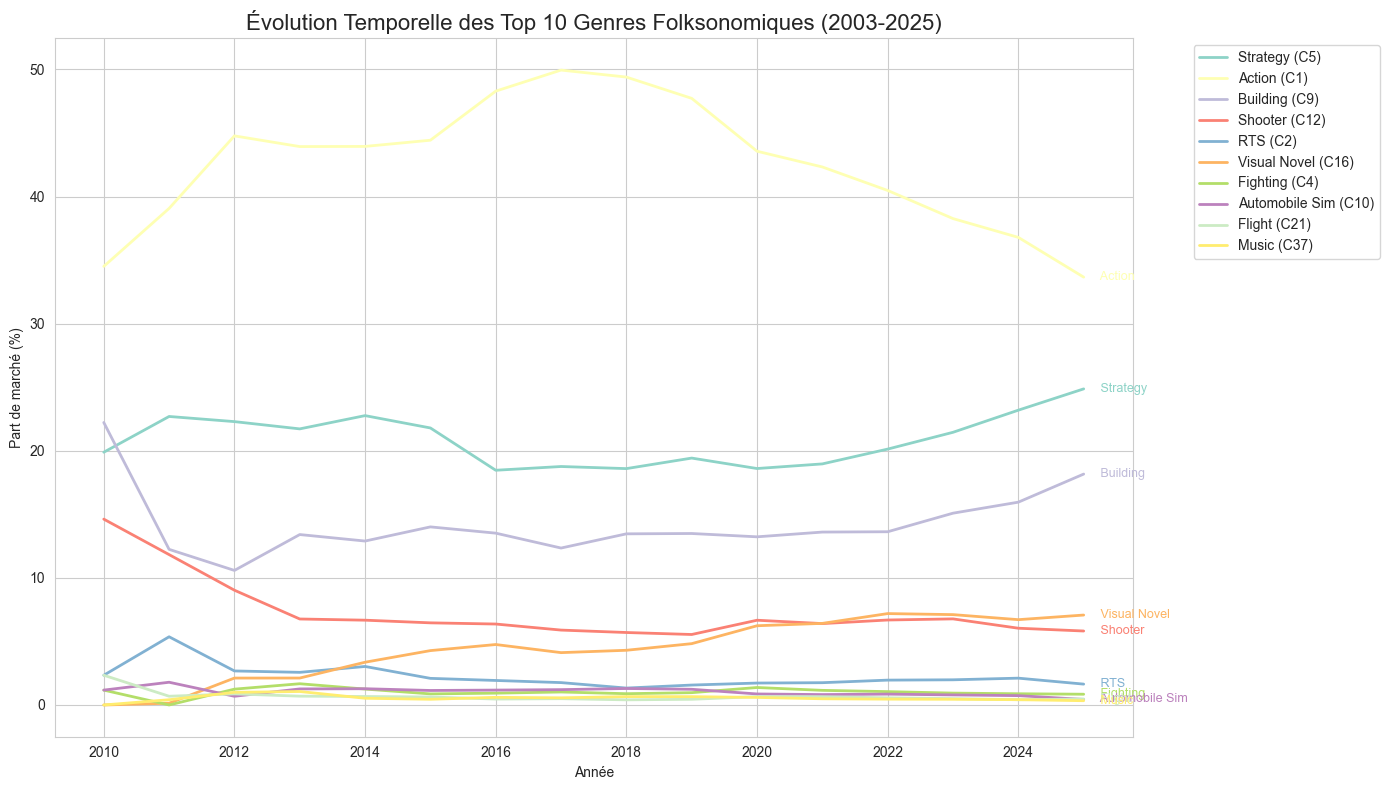

In [58]:
# Copie des tags filtrés
tags_with_date = tags_filtered.copy()

# Conversion de la date au format YYMMDD
def parse_steam_date(date_str):
    try:
        date_str = str(date_str).strip()
        if len(date_str) == 6 and date_str.isdigit():
            year = int("20" + date_str[:2])
            return year
        return pd.to_datetime(date_str, errors='coerce').year
    except:
        return np.nan

tags_with_date['year'] = tags_with_date['game_release_date'].apply(parse_steam_date)

# Associer chaque tag à son cluster
tag_to_cluster = dict(zip(df_clusters['Tag'], df_clusters['Cluster']))
tags_with_date['Cluster'] = tags_with_date['tag'].map(tag_to_cluster)

# Filtrer les années aberrantes
tags_with_date = tags_with_date[(tags_with_date['year'] >= 2010) & (tags_with_date['year'] <= 2025)]

# Compter les occurrences par année et par cluster
cluster_evolution = tags_with_date.groupby(['year', 'Cluster']).size().unstack(fill_value=0)

# Normaliser par année (pour voir la part de marché relative)
cluster_evolution_pct = cluster_evolution.div(cluster_evolution.sum(axis=1), axis=0) * 100

# Visualisation des 10 plus gros clusters
top_clusters = df_clusters['Cluster'].value_counts().head(10).index
plt.figure(figsize=(14, 8))
for cid in top_clusters:
    leader_name = cluster_leaders.get(cid, f"Cluster {cid}")
    line, = plt.plot(cluster_evolution_pct.index, cluster_evolution_pct[cid], label=f"{leader_name} (C{cid})", linewidth=2)

    # Ajouter le nom du genre à la fin de la courbe
    last_year = cluster_evolution_pct.index[-1]
    last_val = cluster_evolution_pct.loc[last_year, cid]
    plt.text(last_year + 0.2, last_val, f" {leader_name}", fontsize=9, color=line.get_color(), va='center')

plt.title("Évolution Temporelle des Top 10 Genres Folksonomiques (2003-2025)", fontsize=16)
plt.xlabel("Année")
plt.ylabel("Part de marché (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
save_plot('plot')
plt.show()

*On remarque que l'Action a toujours été le genre dominant, que les Visual Novels ont connu une forte croissance et aussi que les Shooter ont perdu du terrain.*

## 9. Synthèse et Conclusion

### Évaluation Globale
L'analyse approfondie de la folksonomie Steam révèle une structure latente robuste, bien que complexe.

*   **Performance des Algorithmes** :
    *   **Louvain** reste le choix le plus équilibré pour une taxonomie complète. Il offre une bonne séparation des clusters (Davies-Bouldin favorable) et une cohérence sémantique forte, validée par l'inspection des "leaders" de clusters.
    *   **OPTICS** excelle dans la pureté des clusters (Silhouette élevée) mais rejette trop de tags comme "bruit", ce qui le rend moins adapté pour une couverture exhaustive.
    *   **K-Means** et **Hierarchical** montrent des performances variables, souvent inférieures à Louvain pour ce type de données de graphe.

### Points Forts et Améliorations
*   **Points Forts** : La détection de communautés par graphe (Louvain) capture bien les relations sémantiques naturelles entre les tags. L'analyse de stabilité confirme que ces structures ne sont pas des artefacts aléatoires.
*   **Améliorations Possibles** : Le score de Silhouette global reste modéré, indiquant que de nombreux tags sont à la frontière entre plusieurs genres (ex: "Action-RPG"). Une approche de "fuzzy clustering" (appartenance multiple) pourrait être pertinente pour ces cas limites.

### Implications Ludologiques
Les clusters identifiés ne correspondent pas toujours aux genres marketing traditionnels. On observe l'émergence de :
*   **Micro-genres** très spécifiques (ex: "Creature Collector", "Word Game").
*   **Thématiques transversales** (ex: "Atmospheric", "Relaxing") qui regroupent des jeux de mécaniques très différentes.
*   **Hybridation** : La visualisation 3D montre clairement que les frontières entre les genres sont fluides, formant un continuum plutôt que des boîtes étanches.

### Perspectives Futures
Pour affiner cette taxonomie :
Croiser ces clusters folksonomiques avec des données de gameplay objectives (exemple des images de gameplay par exemple) pour valider leur pertinence fonctionnelle.
